<div align="center">

# 4º PROJETO

| Disciplina | Semestre | Docente | Horário |
| :---: | :---: | :---: | :---: |
| PAM0466 - SISTEMAS INTELIGENTES | 2026.1 | PEDRO THIAGO VALÉRIO DE SOUZA | 3M23 4M45 |

| Discente | Matrícula |
| :---: | :---: |
| ELTON CAIO VIEIRA DE LIMA | 2020010673 |
| LUCAS VIERES ARAÚJO FARIAS | 2025022531 |
</div>

## ATIVIDADES

1. Preparação dos dados: carregue o dataset e recodifique o rótulo de classe para valores numéricos bipolares: +1 para *good* e −1 para *bad*. Verifique se há valores ausentes ou atributos constantes que devam ser removidos antes do treinamento. Em seguida, normalize todos os atributos utilizando a padronização 𝑍-score. Justifique algebricamente a necessidade da normalização para que o processo da regra Delta seja estável.

In [ ]:
import pandas

dataset = pandas.read_csv("dataset/ionosphere.data", header=None)
dataset = dataset.drop(columns = 1)

print("Valores ausentes:", dataset.isnull().sum().sum())

Valores ausentes: 0


Não há valores ausentes, entretanto a segunda coluna é constituída inteiramente de zeros, sendo um atributo constante, e por isso foi removida. A normalização das entradas contribui para incrementar o desempenho do treinamento, pois garante que a superfície de erro não fique distorcida, tornando a execução do algoritmo do gradiente descendente mais estável e rápida.

<hr>

2. Implemente uma rede Adaline para a classificação. Neste caso, pode-se utilizar implementações já disponíveis nas bibliotecas da sklearn. Separe os dados em 80% treino e 20% teste com divisão estratificada. Realize um estudo sobre valores distintos da taxa de aprendizagem (ex: 10<sup>−4</sup>, 10<sup>−3</sup>, 10<sup>−2</sup>, 5 ×10<sup>−2</sup>, 10<sup>−1</sup>), mantendo fixos o número máximo de épocas (𝑁 =200) e o conjunto de treino. Para cada valor, plote a curva de convergência da função de perda em função das épocas de treinamento. Com base nos gráficos um valor de 𝜂 que proporciona convergência mais suave e que resulte em um valor menor da função de perda.

/tmp/ipykernel_6465/3479189003.py:44: RuntimeWarning: overflow encountered in scalar add
  epoch_cost += error ** 2
/tmp/ipykernel_6465/3479189003.py:44: RuntimeWarning: overflow encountered in scalar power
  epoch_cost += error ** 2


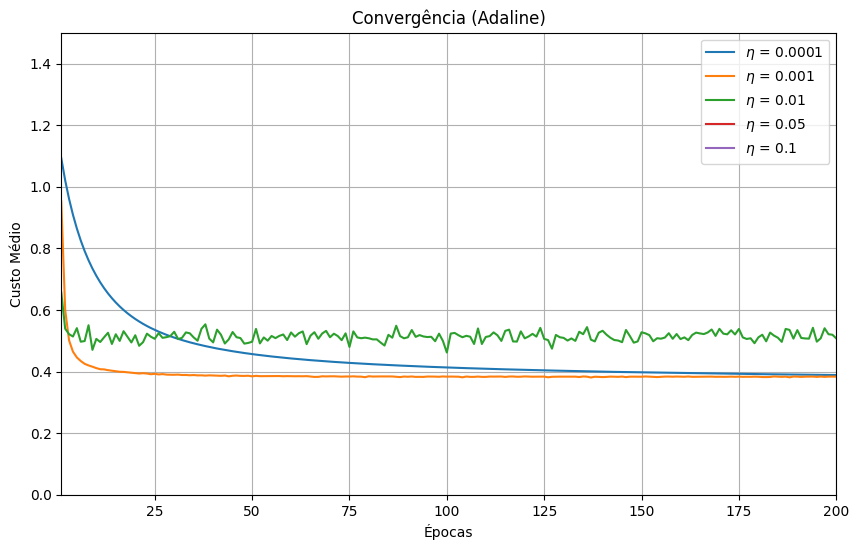

In [ ]:
import numpy
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x, y = dataset.iloc[:, :-1].values, dataset.iloc[:, -1].values

y_adaline = numpy.where(y == 'g', 1, -1)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_adaline,
    test_size = 0.2,
    random_state = 42,
    stratify = y_adaline,
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

class Adaline:
    def __init__(self, learning_rate=0.001, n_epochs=50):
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.weights      = None
        self.cost_        = []

    def fit(self, X_raw, yd):
        X = numpy.column_stack((-1.0*numpy.ones(X_raw.shape[0]), X_raw))
        w = 0.1*numpy.random.randn(X.shape[1])
        n_samples = X.shape[0]

        indexes = numpy.arange(n_samples)

        for _ in range(self.n_epochs):
            numpy.random.shuffle(indexes)
            epoch_cost = 0.0
            for idx in indexes:
                u           = numpy.dot(X[idx,:], w)
                error       = yd[idx] - u
                w          += self.lr * X[idx,:] * error
                epoch_cost += error ** 2
            self.cost_.append(epoch_cost / (n_samples))
        
        self.weights = w
        return self

    def predict(self, X_raw):
        X = numpy.column_stack((-1.0*numpy.ones(X_raw.shape[0]), X_raw))
        u = numpy.dot(X, self.weights)
        return numpy.where(u >= 0.0, 1, -1)

learning_rate = [10**-4, 10**-3, 10**-2, 5 * 10**-2, 10**-1]
epochs = 200

plt.figure(figsize = (10, 6))

for eta in learning_rate:
    adaline = Adaline(learning_rate=eta, n_epochs=epochs)
    adaline.fit(x_train, y_train)

    plt.plot(range(1, epochs + 1), adaline.cost_, label=f"$\eta$ = {eta}")

plt.xlabel("Épocas")
plt.ylabel("Custo Médio")
plt.title("Convergência (Adaline)")
plt.grid()
plt.xlim(1, epochs)
plt.ylim(0, 1.5)
plt.legend()
plt.show()

Com base na análise do gráfico, o valor de $\eta$ que proporcionou a convergência mais rápida e que resultou no menor valor da função de perda ao final das 200 épocas foi 10<sup>-3</sup> (curva laranja). Valores maiores (0.05 e 0.1) apresentaram oscilação ou divergência e nem sequer apareceram na escala do gráfico, causando *overflow*. $\eta$ = 0.0001 (curva azul) convergiu de forma excessivamente lenta. A curva verde desceu rápido mas se tornou instável logo em seguida.

<hr>

3. Após treinar com o melhor 𝜂 identificado na atividade anterior, classifique as amostras de teste. Calcule e apresente a matriz de confusão, a acurácia global e as métricas de precisão, *recall* e F1-score.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

adaline = Adaline(learning_rate = 10**-3, n_epochs = 200)
adaline.fit(x_train, y_train)

y_pred = adaline.predict(x_test)

confusionMatrix = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão:")
print(confusionMatrix)

print('Acurácia  :', accuracy_score(y_test, y_pred))
print('Precisão  :', precision_score(y_test, y_pred))
print('Recall    :', recall_score(y_test, y_pred))
print('F1-Score  :', f1_score(y_test, y_pred))

Matriz de Confusão:
[[19  6]
 [ 0 46]]
Acurácia  : 0.9154929577464789
Precisão  : 0.8846153846153846
Recall    : 1.0
F1-Score  : 0.9387755102040816


As métricas obtidas demonstram que o modelo apresentou um desempenho satisfatório na classificação dos dados, alcançando acurácia de aproximadamente 91,5% e F1-Score de 93,9%, o que indica bom equilíbrio entre precisão e recall. Além disso, o recall igual a 1,0 mostra que o modelo conseguiu identificar corretamente todas as amostras da classe positiva considerada na avaliação. Entretanto, a matriz de confusão mostra a ocorrência de 6 classificações incorretas envolvendo a classe bad, indicando que ainda existem casos em que falhas ou interferências podem não ser detectadas corretamente. Mas no geral, o modelo apresenta uma boa capacidade de classificação.

<hr>

4. Em uma aplicação real de monitoramento automático, o erro mais crítico seria classificar sinais da classe bad como good, pois isso significa que falhas ou interferências no sistema não seriam detectadas. A matriz de confusão mostrou 6 ocorrências desse tipo de erro, indicando que, apesar da alta acurácia (91,5%) e do bom desempenho geral do modelo, ainda existem casos em que problemas reais podem passar despercebidos. Em sistemas de comunicação e monitoramento, esse tipo de falha é mais preocupante do que falsos alarmes, pois compromete a confiabilidade e a segurança da operação.